In [1]:
from graphen import grphn
import numpy as np 
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

In [ ]:
G = grphn()

# Calcul DOS
E_DOS, DOS, DOSp = G.DOS_chunked(n_points=40000, n_bins=10000,E_max=2)
DOS_save = DOS
# quick check
print(f"Nombre de points k dans la FBZ : {G.n_k_FBZ}")
print(f"E_DOS : [{E_DOS.min():.2f}, {E_DOS.max():.2f}] eV")
print(f"DOS max : {DOS.max():.4f} eV⁻¹")
print(f"Somme DOS * dE = {np.sum(DOS) * (E_DOS[1]-E_DOS[0]):.3f} ")

Nombre de points k dans la FBZ : 346398612
E_DOS : [-2.00, 2.00] eV
DOS max : 0.2413 eV⁻¹
Somme DOS * dE = 0.415 


In [9]:
bruit_sigma = 3

# On applique le lissage naturel
DOS_TBG = gaussian_filter1d(DOS, sigma=bruit_sigma)
DOS_dr_ana = G.DOS_Dirac_ana(E_DOS)

In [10]:
msk = E_DOS>=0
pE_DOS = E_DOS[msk]
pDOSTB = DOS[msk]
pDOS_TBG= DOS_TBG[msk]
pDOS_dr_ana = DOS_dr_ana[msk]

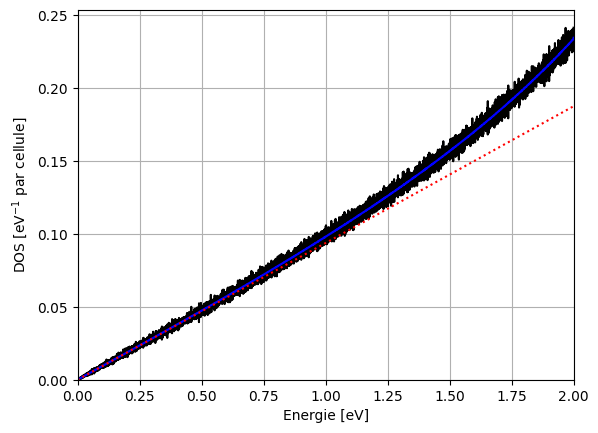

In [11]:
plt.plot(pE_DOS, pDOSTB, color='black', label="Tight Binding")
plt.plot(pE_DOS, pDOS_TBG, color='blue', label="Tight Binding lissed")
plt.plot(pE_DOS, pDOS_dr_ana, color='red', linestyle=':', label="Cône Dirac (Théorique Analytique)")

plt.xlabel("Energie [eV]")
plt.ylabel(r"DOS [eV$^{-1}$ par cellule]")
plt.xlim(0, 2)
plt.ylim(bottom=0)
plt.grid()

plt.show()

In [12]:
er_an = np.abs(pDOSTB-pDOS_dr_ana)/pDOSTB *100
er_G = np.abs(pDOS_TBG-pDOS_dr_ana)/pDOSTB *100

/tmp/ipykernel_61152/989721256.py:1: RuntimeWarning: divide by zero encountered in divide
  er_an = np.abs(pDOSTB-pDOS_dr_ana)/pDOSTB *100
/tmp/ipykernel_61152/989721256.py:2: RuntimeWarning: divide by zero encountered in divide
  er_G = np.abs(pDOS_TBG-pDOS_dr_ana)/pDOSTB *100


/tmp/ipykernel_61152/3034329328.py:7: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(0,100)


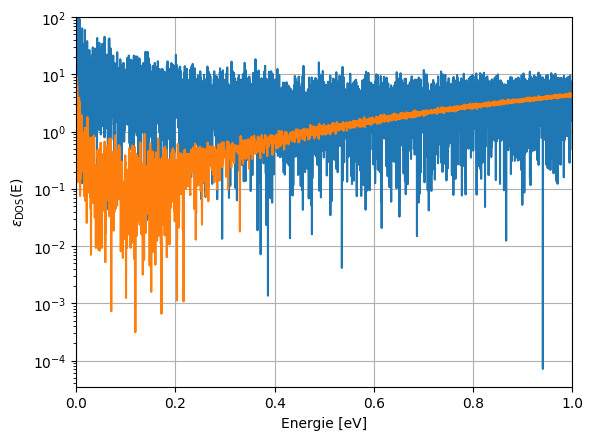

In [14]:
plt.semilogy(pE_DOS, er_an)
plt.semilogy(pE_DOS, er_G)

plt.xlabel("Energie [eV]")
plt.ylabel(r"$\epsilon_{\text{DOS}}$(E)")
plt.xlim(0, 1)
plt.ylim(0,100)
plt.grid()
plt.show()

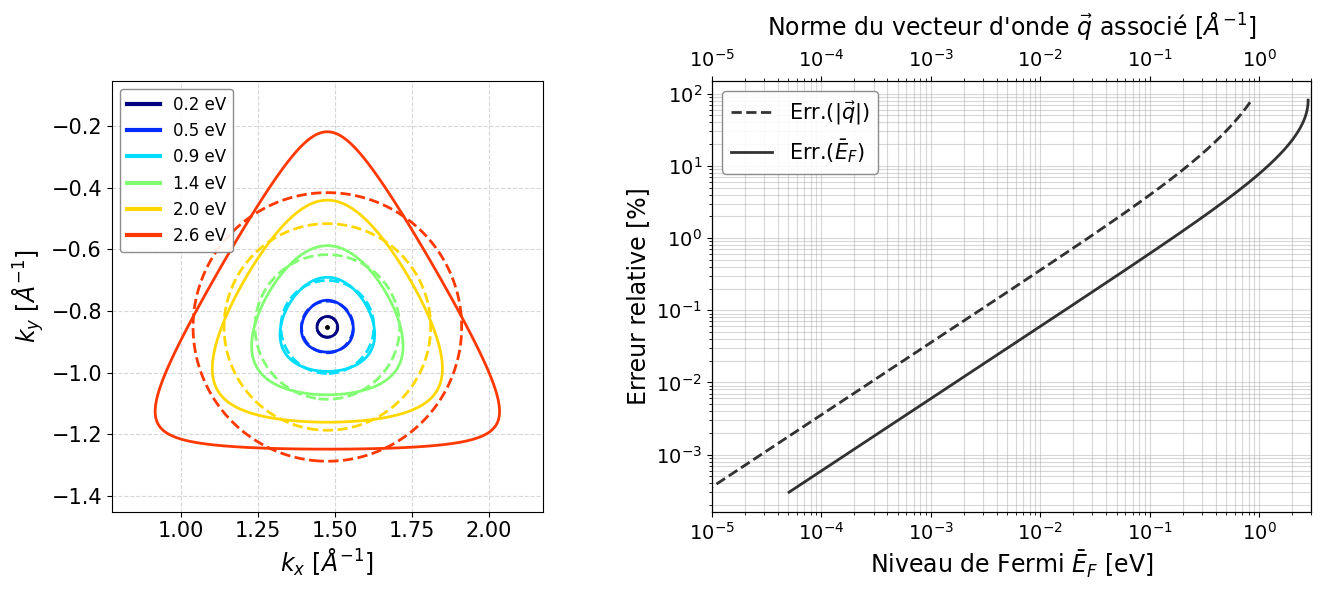

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

# 1. Initialisation de ta classe (en supposant que grphn est importé)
graphene = grphn()

# 2. Point K
K_vec = graphene.b_1 * (2/3) + graphene.b_2 * (1/3)
K_x = K_vec[0]
K_y = K_vec[1]

# 3. Grille kx, ky
dkx = 0.7
dky = 0.7
kx = np.linspace(K_x - dkx, K_x + dkx, 400)
ky = np.linspace(K_y - dky+0.1, K_y + dky+0.1, 400)
kxx, kyy = np.meshgrid(kx, ky)

# 4. Calcul Tight-Binding
graphene.kxx = kxx
graphene.kyy = kyy
_, E_TB = graphene.E_Tb(epsi=0)

# 5. Calcul Dirac
qxx = kxx - K_x
qyy = kyy - K_y
_, E_Dirac = graphene.Dirac_c(qxx, qyy, epsi=0)

# ==========================================
# 6. Affichage Pro
# ==========================================
fig = plt.figure(figsize=(14, 6))
ax = fig.add_subplot(121)

levels = np.array([0.2, 0.5, 0.9, 1.4, 2.0, 2.6])

# Ta palette de couleur 
import matplotlib.cm as cm

# Pour générer automatiquement N couleurs à partir de la palette 'jet' :
# colors = plt.cm.coolwarm(np.linspace(0, 1, len(levels)))
colors = ['#003d5c', '#464c89', '#954e9b', '#dd4d88', '#ff6b59', '#ffa600'][::-1]
colors = plt.cm.jet(np.linspace(0.0, 0.85, len(levels)))
# Tracés
cs_TB = ax.contour(kxx, kyy, E_TB, levels=levels, colors=colors, linestyles='solid', linewidths=2)
cs_Dirac = ax.contour(kxx, kyy, E_Dirac, levels=levels, colors=colors, linestyles='dashed', linewidths=2)

# Point K
ax.plot(K_x, K_y, 'o', markersize=2.5, label='Point K', zorder=5, color='black')

# ---------------------------------------------------------
# LÉGENDES SUR MESURE (Le secret pour un rendu pro)
# ---------------------------------------------------------

# Légende 1 : Les Modèles (Styles de ligne)
line_tb = mlines.Line2D([], [], color='black', linestyle='solid', lw=2, label='Liaison forte')
line_dir = mlines.Line2D([], [], color='black', linestyle='dashed', lw=2, label='Approx. conique')
point_k = mlines.Line2D([], [], color='black', marker='o', linestyle='None', markersize=5, label='Point K')


# Légende 2 : Les Énergies (Couleurs)
energy_handles = []
for c, lvl in zip(colors, levels):
    energy_handles.append(mlines.Line2D([], [], color=c, lw=3, label=f'{lvl:.1f} eV'))

# On place la légende des énergies en dehors du graphe (ou dans un coin dégagé)
legend_energies = ax.legend(handles=energy_handles, 
                            loc='upper left', framealpha=0.9, edgecolor='gray',fontsize=12)

# ---------------------------------------------------------
# Mise en forme du graphe
# ---------------------------------------------------------
ax.set_aspect('equal')
ax.set_xlabel(r'$k_x \ [\AA^{-1}]$', fontsize=17)
ax.set_ylabel(r'$k_y \ [\AA^{-1}]$', fontsize=17)
ax.tick_params(axis='both', labelsize=15)
# Grille discrète mais présente
ax.grid(True, linestyle='--', alpha=0.5)



# 1. Initialisation de ta classe (en supposant que grphn est importé)
graphene = grphn()

# 2. Point K
K_vec = graphene.b_1 * (2/3) + graphene.b_2 * (1/3)
M_vec = graphene.b_1 * (1/2) + graphene.b_2 * (1/2)
K_x = K_vec[0]
K_y = K_vec[1]
M_x = M_vec[0]
M_y = M_vec[1]

# 3. Grille kx, ky
kx = np.linspace(K_x ,  M_x, 100000)
ky = np.linspace(K_y ,  M_y, 100000)


# 4. Calcul Tight-Binding
graphene.kxx = kx
graphene.kyy = ky
_, E_TB = graphene.E_Tb(epsi=0)

# 5. Calcul Dirac
qxx = kx - K_x
qyy = ky - K_y
_, E_Dirac = graphene.Dirac_c(qxx, qyy, epsi=0)

E_TB = E_TB[1:]
E_Dirac = E_Dirac[1:]

ax1 = fig.add_subplot(122)

# 1. Courbe sur l'axe du bas : Niveau de Fermi
ax1.loglog(E_TB, (np.abs(E_TB-E_Dirac)/E_TB)*100, color='black', linewidth=2, alpha=0.8, label=r"Err.($\bar{E}_F$)")
ax1.set_xlabel(r"Niveau de Fermi $\bar{E}_F$ [eV]", fontsize=17)
ax1.set_ylabel(r"Erreur relative [%]", fontsize=17)
ax1.tick_params(axis='both', labelsize=14)
ax1.grid(True, which="both", linestyle="-", alpha=0.5)
ax1.set_xlim(1e-5,3)

# 2. Courbe sur l'axe du haut (twiny) : Vecteur d'onde q
ax2 = ax1.twiny()
ax2.loglog(np.abs(ky[1:]-K_y), (np.abs(E_TB-E_Dirac)/E_TB)*100, color='black', ls='--', linewidth=2, alpha=0.8, label=r"Err.($|\vec{q}|$)")
ax2.set_xlabel(r"Norme du vecteur d'onde $\vec{q}$ associé $[\AA^{-1}]$", fontsize=17, labelpad=10)
ax2.tick_params(axis='x', labelsize=14)

# 1. On récupère les lignes et les textes des DEUX axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

# 2. On les additionne et on crée UNE SEULE légende sur ax1
ax1.legend(lines2 + lines1, labels2 + labels1, 
           loc='upper left', # ou 'best', 'upper right', etc.
           fontsize=15,       # "Une bonne taille" pour ta présentation
           framealpha=0.9,    # Un fond très légèrement transparent
           edgecolor='gray')  # Une belle bordure
ax2.set_xlim(ax1.get_xlim())
plt.tight_layout()
plt.savefig('Levels_coneVStb2.jpg',dpi=600)


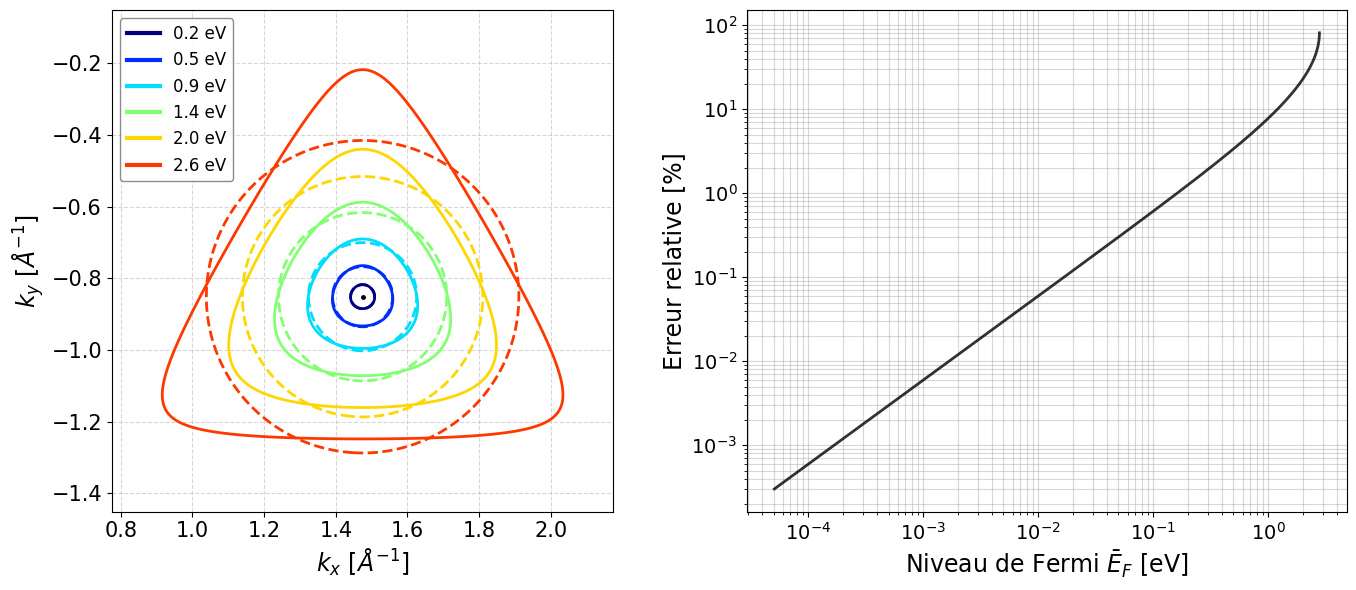

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

# 1. Initialisation de ta classe (en supposant que grphn est importé)
graphene = grphn()

# 2. Point K
K_vec = graphene.b_1 * (2/3) + graphene.b_2 * (1/3)
K_x = K_vec[0]
K_y = K_vec[1]

# 3. Grille kx, ky
dkx = 0.7
dky = 0.7
kx = np.linspace(K_x - dkx, K_x + dkx, 400)
ky = np.linspace(K_y - dky+0.1, K_y + dky+0.1, 400)
kxx, kyy = np.meshgrid(kx, ky)

# 4. Calcul Tight-Binding
graphene.kxx = kxx
graphene.kyy = kyy
_, E_TB = graphene.E_Tb(epsi=0)

# 5. Calcul Dirac
qxx = kxx - K_x
qyy = kyy - K_y
_, E_Dirac = graphene.Dirac_c(qxx, qyy, epsi=0)

# ==========================================
# 6. Affichage Pro
# ==========================================
fig = plt.figure(figsize=(14, 6))
ax = fig.add_subplot(121)

levels = np.array([0.2, 0.5, 0.9, 1.4, 2.0, 2.6])

# Ta palette de couleur 
import matplotlib.cm as cm

# Pour générer automatiquement N couleurs à partir de la palette 'jet' :
# colors = plt.cm.coolwarm(np.linspace(0, 1, len(levels)))
colors = ['#003d5c', '#464c89', '#954e9b', '#dd4d88', '#ff6b59', '#ffa600'][::-1]
colors = plt.cm.jet(np.linspace(0.0, 0.85, len(levels)))
# Tracés
cs_TB = ax.contour(kxx, kyy, E_TB, levels=levels, colors=colors, linestyles='solid', linewidths=2)
cs_Dirac = ax.contour(kxx, kyy, E_Dirac, levels=levels, colors=colors, linestyles='dashed', linewidths=2)

# Point K
ax.plot(K_x, K_y, 'o', markersize=2.5, label='Point K', zorder=5, color='black')

# ---------------------------------------------------------
# LÉGENDES SUR MESURE (Le secret pour un rendu pro)
# ---------------------------------------------------------

# Légende 1 : Les Modèles (Styles de ligne)
line_tb = mlines.Line2D([], [], color='black', linestyle='solid', lw=2, label='Liaison forte')
line_dir = mlines.Line2D([], [], color='black', linestyle='dashed', lw=2, label='Approx. conique')
point_k = mlines.Line2D([], [], color='black', marker='o', linestyle='None', markersize=5, label='Point K')


# Légende 2 : Les Énergies (Couleurs)
energy_handles = []
for c, lvl in zip(colors, levels):
    energy_handles.append(mlines.Line2D([], [], color=c, lw=3, label=f'{lvl:.1f} eV'))

# On place la légende des énergies en dehors du graphe (ou dans un coin dégagé)
legend_energies = ax.legend(handles=energy_handles, 
                            loc='upper left', framealpha=0.9, edgecolor='gray',fontsize=12)

# ---------------------------------------------------------
# Mise en forme du graphe
# ---------------------------------------------------------
ax.set_aspect('equal')
ax.set_xlabel(r'$k_x \ [\AA^{-1}]$', fontsize=17)
ax.set_ylabel(r'$k_y \ [\AA^{-1}]$', fontsize=17)
ax.tick_params(axis='both', labelsize=15)
# Grille discrète mais présente
ax.grid(True, linestyle='--', alpha=0.5)



# 1. Initialisation de ta classe (en supposant que grphn est importé)
graphene = grphn()

# 2. Point K
K_vec = graphene.b_1 * (2/3) + graphene.b_2 * (1/3)
M_vec = graphene.b_1 * (1/2) + graphene.b_2 * (1/2)
K_x = K_vec[0]
K_y = K_vec[1]
M_x = M_vec[0]
M_y = M_vec[1]

# 3. Grille kx, ky
kx = np.linspace(K_x ,  M_x, 100000)
ky = np.linspace(K_y ,  M_y, 100000)


# 4. Calcul Tight-Binding
graphene.kxx = kx
graphene.kyy = ky
_, E_TB = graphene.E_Tb(epsi=0)

# 5. Calcul Dirac
qxx = kx - K_x
qyy = ky - K_y
_, E_Dirac = graphene.Dirac_c(qxx, qyy, epsi=0)

E_TB = E_TB[1:]
E_Dirac = E_Dirac[1:]

ax1 = fig.add_subplot(122)

# 1. Courbe sur l'axe du bas : Niveau de Fermi
ax1.loglog(E_TB, (np.abs(E_TB-E_Dirac)/E_TB)*100, color='black', linewidth=2, alpha=0.8, label=r"Err.($\bar{E}_F$)")
ax1.set_xlabel(r"Niveau de Fermi $\bar{E}_F$ [eV]", fontsize=17)
ax1.set_ylabel(r"Erreur relative [%]", fontsize=17)
ax1.tick_params(axis='both', labelsize=14)
ax1.grid(True, which="both", linestyle="-", alpha=0.5)

plt.tight_layout()
plt.savefig('Levels_coneVStb2.jpg',dpi=600)


In [10]:
A = (np.abs(E_TB - E_Dirac) / E_TB) * 100

i = np.argmin(np.abs(A - 1))
print(f"Indice: {i}, Valeur: {A[i]}")
print(f"Energie: {E_TB[i]}")

Indice: 3212, Valeur: 0.9999755268593095
Energie: 0.16156269042198967


In [3]:
raphene = grphn()

# 2. Point K
K_vec = graphene.b_1 * (2/3) + graphene.b_2 * (1/3)
M_vec = graphene.b_1 * (1/2) + graphene.b_2 * (1/2)
K_x = K_vec[0]
K_y = K_vec[1]
M_x = M_vec[0]
M_y = M_vec[1]

q_y = 3e-2

# 3. Grille kx, ky
kx = K_x
ky = q_y + K_y


# 4. Calcul Tight-Binding
graphene.kxx = kx
graphene.kyy = ky
_, E_TB = graphene.E_Tb(epsi=0)

# 5. Calcul Dirac
qxx = kx - K_x
qyy = ky - K_y
_, E_Dirac = graphene.Dirac_c(qxx, qyy, epsi=0)

print(E_TB,E_Dirac)




0.17697413377114712 0.1789200000000001


In [9]:
A = np.log10((np.abs(E_TB-E_Dirac)/E_TB))
B = np.log10(E_TB)
print((A[1:51]-A[:50])/(B[1:51]-B[:50]))

from scipy.stats import linregress

blbl = 1000

pente, intercept, r_value, _, _ = linregress(B[:blbl], A[:blbl])
print(f"Pente (régression) : {pente:.6e}, R² = {r_value**2:.6e}")

[1.00003444 1.00002228 1.00004772 1.00005113 1.00006622 1.00007973
 1.00009167 1.00010237 1.0001142  1.00012735 1.00013973 1.00015066
 1.00016291 1.00017551 1.00018802 1.00019904 1.00021097 1.00022438
 1.00023519 1.00024869 1.00025943 1.00027246 1.00028372 1.00029685
 1.00030785 1.00032091 1.00033216 1.00034448 1.00035705 1.00036917
 1.00038056 1.00039293 1.0004054  1.00041737 1.00042915 1.00044134
 1.00045373 1.00046579 1.00047756 1.00048956 1.00050224 1.00051366
 1.00052652 1.00053797 1.00055062 1.00056211 1.00057483 1.00058636
 1.0005989  1.00061061]
Pente (régression) : 1.003101e+00, R² = 9.999970e-01
